# Draft

In [1]:
import lightning.pytorch as pl
import webdataset as wds
import torch
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import io
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from skimage.color import rgb2hed, hed2rgb

import glob


/home/jaffolabi/Documents/lung_map/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
%load_ext autoreload
%autoreload 1
%aimport ...

In [3]:
from src.segmentation.constants import PATH_SEG_DATA
from src.segmentation.models.dev.data_module import SegmentationDataModule, SegmentationDataModule2, get_path_shards

In [ ]:
data_module = SegmentationDataModule(
        train_urls=get_path_shards('train-full'),
        val_urls=get_path_shards('val'),
        test_urls=get_path_shards('test'),
        batch_size=4, 
        num_workers=0
)

In [10]:
get_path_shards('train')

['/home/jaffolabi/Documents/lung_map/data/segmentation/shards/dataset-train-000000.tar',
 '/home/jaffolabi/Documents/lung_map/data/segmentation/shards/dataset-train-rare-000000.tar',
 '/home/jaffolabi/Documents/lung_map/data/segmentation/shards/dataset-train-common-000000.tar']

In [7]:
train_loader = data_module.train_dataloader()
val_loader = data_module.val_dataloader()
test_loader = data_module.test_dataloader()

IndexError: list index out of range

/home/jaffolabi/Documents/lung_map/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== VÉRIFICATION DES TENSEURS ===
Images batch shape : torch.Size([4, 3, 224, 224]) (Attendu : [Batch, 3, H, W])
Images dtype       : torch.float32 (Attendu : torch.float32)
Valeurs Images     : Min=-2.12, Max=2.64

Masks batch shape  : torch.Size([4, 224, 224]) (Attendu : [Batch, H, W])
Masks dtype        : torch.int64 (Attendu : torch.int64 ou torch.long)
Classes présentes  : [0, 1, 2, 3]


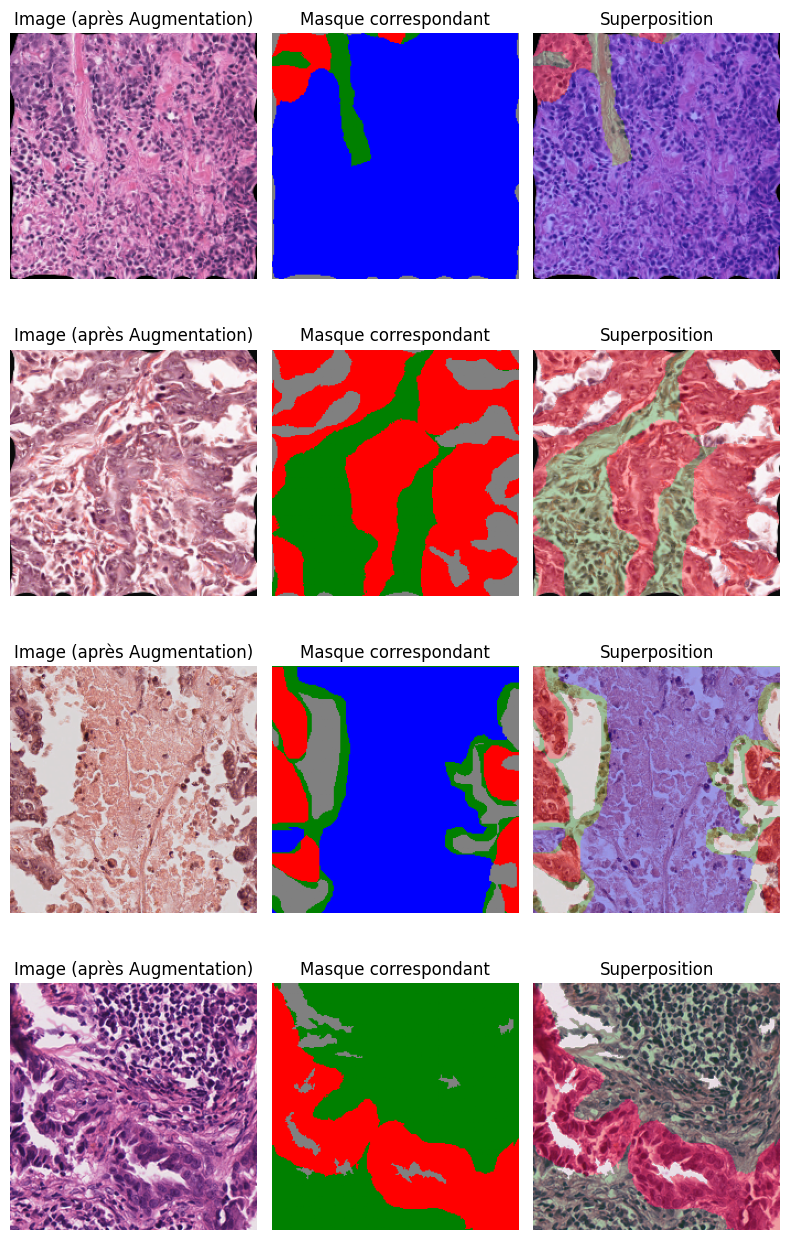

In [7]:
images, masks = next(iter(train_loader))

class_dict = {
    0: ("other", "gray"),
    1: ("tumeur", "red"),      
    2: ("necrosis", "blue"), 
    3: ("stroma", "green"),
}

# Extraction des couleurs pour créer la Colormap fixe
colors = [class_dict[i][1] for i in sorted(class_dict.keys())]
custom_cmap = ListedColormap(colors)

# Valeurs min et max pour forcer l'alignement des couleurs
vmin = 0
vmax = len(class_dict) - 1

print("=== VÉRIFICATION DES TENSEURS ===")
print(f"Images batch shape : {images.shape} (Attendu : [Batch, 3, H, W])")
print(f"Images dtype       : {images.dtype} (Attendu : torch.float32)")
print(f"Valeurs Images     : Min={images.min():.2f}, Max={images.max():.2f}\n")

print(f"Masks batch shape  : {masks.shape} (Attendu : [Batch, H, W])")
print(f"Masks dtype        : {masks.dtype} (Attendu : torch.int64 ou torch.long)")
print(f"Classes présentes  : {torch.unique(masks).tolist()}")

fig, axes = plt.subplots(len(images), 3, figsize=(8, 3 * len(images) + 1))

for i in range(len(images)):

    # 4. Affichage visuel du premier élément du batch
    # PyTorch utilise le format [Canal, Hauteur, Largeur]. 
    # Matplotlib veut [Hauteur, Largeur, Canal]. On utilise .permute() pour réarranger.
    img_display = images[i].permute(1, 2, 0).numpy()
    mask_display = masks[i].numpy()

    # --- ATTENTION : GESTION DE LA NORMALISATION ---
    # Si vous avez utilisé A.Normalize (ImageNet) dans Albumentations, 
    # l'image aura des couleurs bizarres et des valeurs négatives.
    # Pour l'afficher correctement, on doit "dé-normaliser" visuellement :
    if images.min() < 0:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1)


    #plt.subplot(len(images), 3, i+1)
    axes[i, 0].set_title("Image (après Augmentation)")
    axes[i, 0].imshow(img_display)
    axes[i, 0].axis('off')

    #plt.subplot(len(images), 3, i+2)
    axes[i, 1].set_title("Masque correspondant")
    axes[i, 1].imshow(mask_display, cmap=custom_cmap, vmin=vmin, vmax=vmax)
    axes[i, 1].axis('off')

    #plt.subplot(len(images), 3, 3)
    axes[i, 2].set_title("Superposition")
    axes[i, 2].imshow(img_display)
    mask_overlay = np.ma.masked_where(mask_display == 0, mask_display)
    axes[i, 2].imshow(mask_overlay, cmap=custom_cmap, vmin=vmin, vmax=vmax, alpha=0.3)
    axes[i, 2].axis('off')

plt.tight_layout()

In [7]:
def get_nb_elements(loader):
    sample_count = 0
    label_count = dict()
    for images, masks in loader:
        sample_count += len(images)
        for m in masks:
            labels, effs = np.unique(m, return_counts=True)
            for l, eff in zip(labels, effs):
                if l in label_count:
                    label_count[l] += eff
                else:
                    label_count[l] = eff

    return sample_count, label_count

train_stats = get_nb_elements(data_module.train_dataloader())
val_stats = get_nb_elements(data_module.val_dataloader())
test_stats = get_nb_elements(data_module.test_dataloader())

print(f'Train loader: {train_stats[0]} samples \n {train_stats[1]}')
print(f'Val loader: {val_stats[0]} samples \n {val_stats[1]}')
print(f'Test loader: {test_stats[0]} samples \n {test_stats[1]}')

/home/jaffolabi/Documents/lung_map/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Train loader: 1649 samples 
 {np.int64(0): np.int64(6352305), np.int64(1): np.int64(32395093), np.int64(3): np.int64(38752679), np.int64(2): np.int64(5240147)}
Val loader: 405 samples 
 {np.int64(0): np.int64(1077554), np.int64(1): np.int64(9480531), np.int64(3): np.int64(8469748), np.int64(2): np.int64(1293447)}
Test loader: 524 samples 
 {np.int64(0): np.int64(1877413), np.int64(3): np.int64(14042750), np.int64(1): np.int64(9375249), np.int64(2): np.int64(996812)}


In [11]:
def get_class_weight(loader, square_root=False):
    _, label_count = get_nb_elements(loader)
    total_pxl = np.sum(list(label_count.values()))
    freq = {int(label): count/total_pxl for label, count in label_count.items()}
    inv_feq = np.ones(len(freq))
    for label in freq:
        inv_feq[label] = 1/freq[label]
    if square_root:
        weights = np.sqrt(inv_feq) / np.sqrt(inv_feq).mean()
    else:
        weights = inv_feq / inv_feq.mean()
    return freq